In [1]:
!pip install pandas matplotlib tabulate

In [2]:
import pandas as pd
import uuid
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate
import re

In [3]:
users = []
applications = []

stages = [
    "Saved",
    "Applied",
    "OA",
    "Interview",
    "Offer",
    "Rejected"
]

In [4]:
def register(name,email,password):

    user = {
        "id":str(uuid.uuid4()),
        "name":name,
        "email":email,
        "password":password
    }

    users.append(user)

    print("User Registered")

register(
    "Student",
    "student@gmail.com",
    "1234"
)

User Registered


In [5]:
def add_application(

        company,
        role,
        stage,
        deadline,
        location,
        jd_text

):

    app = {

        "id":str(uuid.uuid4()),
        "company":company,
        "role":role,
        "stage":stage,
        "deadline":deadline,
        "location":location,
        "jd_text":jd_text,
        "created":datetime.now()

    }

    applications.append(app)

    print("Application Added")

In [6]:
add_application(

    "Google",
    "Software Engineer",
    "Applied",
    "2026-06-20",
    "Bangalore",

    """
    Looking for Python SQL React
    Docker Git Cloud
    """

)

add_application(

    "Amazon",
    "Backend Developer",
    "Interview",
    "2026-06-15",
    "Pune",

    """
    Node Express MongoDB
    REST APIs Docker
    """

)

add_application(

    "Microsoft",
    "Intern",
    "Offer",
    "2026-06-01",
    "Remote",

    """
    Python ML SQL
    """

)

Application Added
Application Added
Application Added


In [7]:
def show_applications():

    df = pd.DataFrame(applications)

    print(

        tabulate(
            df,
            headers="keys",
            tablefmt="grid"
        )

    )

show_applications()

+----+--------------------------------------+-----------+-------------------+-----------+------------+------------+------------------------------+----------------------------+
|    | id                                   | company   | role              | stage     | deadline   | location   | jd_text                      | created                    |
+====+======================================+===========+===================+===========+============+============+==============================+============================+
|  0 | 00b67097-50e5-4fc0-8a00-5b4ac8ab4bfd | Google    | Software Engineer | Applied   | 2026-06-20 | Bangalore  | Looking for Python SQL React | 2026-05-28 10:02:46.446925 |
|    |                                      |           |                   |           |            |            |     Docker Git Cloud         |                            |
+----+--------------------------------------+-----------+-------------------+-----------+------------+------------+-----

In [9]:
def filter_stage(stage):

    result = [

        x for x in applications

        if x["stage"]==stage

    ]

    print(

        tabulate(

            pd.DataFrame(result),

            headers="keys",

            tablefmt="grid"

        )

    )

filter_stage(
    "Interview"
)

+----+--------------------------------------+-----------+-------------------+-----------+------------+------------+------------------------------+----------------------------+
|    | id                                   | company   | role              | stage     | deadline   | location   | jd_text                      | created                    |
+====+======================================+===========+===================+===========+============+============+==============================+============================+
|  0 | 00b67097-50e5-4fc0-8a00-5b4ac8ab4bfd | Google    | Software Engineer | Interview | 2026-06-20 | Bangalore  | Looking for Python SQL React | 2026-05-28 10:02:46.446925 |
|    |                                      |           |                   |           |            |            |     Docker Git Cloud         |                            |
+----+--------------------------------------+-----------+-------------------+-----------+------------+------------+-----

In [10]:
skills = [

    "python",
    "sql",
    "react",
    "node",
    "docker",
    "mongodb",
    "git",
    "cloud",
    "express"

]

def extract_keywords(text):

    text=text.lower()

    found=[]

    for skill in skills:

        if re.search(skill,text):

            found.append(skill)

    return found


for app in applications:

    print(

        app["company"],

        extract_keywords(

            app["jd_text"]

        )

    )

Google ['python', 'sql', 'react', 'docker', 'git', 'cloud']
Amazon ['node', 'docker', 'mongodb', 'express']
Microsoft ['python', 'sql']


In [11]:
total = len(applications)

responses = len(

    [

        x for x in applications

        if x["stage"]

        in [

            "Interview",

            "Offer"

        ]

    ]

)

rate = responses / total *100

print(

    "Response Rate:",

    round(rate,2),

    "%"

)

Response Rate: 100.0 %


In [12]:
df = pd.DataFrame(

    applications

)

df.to_csv(

    "job_tracker.csv",

    index=False

)

print(

    "CSV Saved"

)

CSV Saved


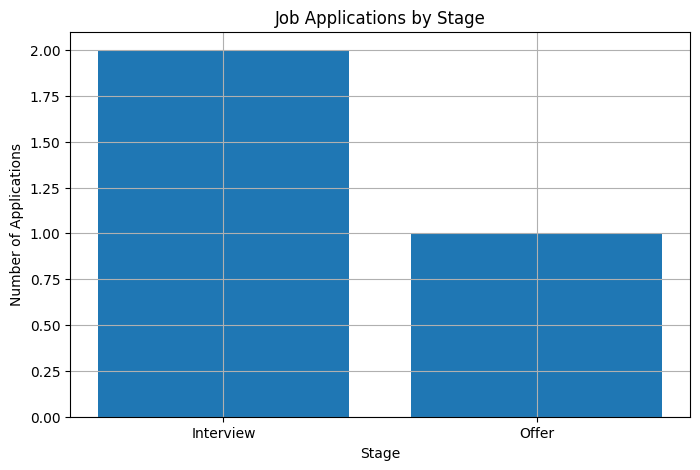

In [13]:
import matplotlib.pyplot as plt

stage_count = {}

for app in applications:

    stage = app["stage"]

    stage_count[stage] = stage_count.get(stage,0)+1

plt.figure(figsize=(8,5))

plt.bar(

    list(stage_count.keys()),
    list(stage_count.values())

)

plt.title(

    "Job Applications by Stage"

)

plt.xlabel(

    "Stage"

)

plt.ylabel(

    "Number of Applications"

)

plt.grid()

plt.show()

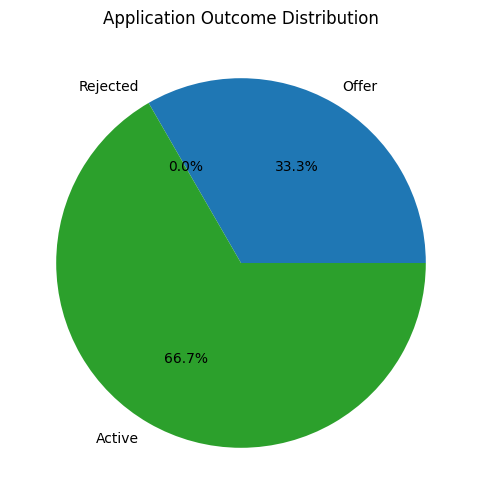

In [14]:
offer = 0
reject = 0
active = 0

for app in applications:

    if app["stage"]=="Offer":

        offer +=1

    elif app["stage"]=="Rejected":

        reject +=1

    else:

        active +=1

labels = [

    "Offer",
    "Rejected",
    "Active"

]

values = [

    offer,
    reject,
    active

]

plt.figure(figsize=(6,6))

plt.pie(

    values,

    labels=labels,

    autopct='%1.1f%%'

)

plt.title(

    "Application Outcome Distribution"

)

plt.show()

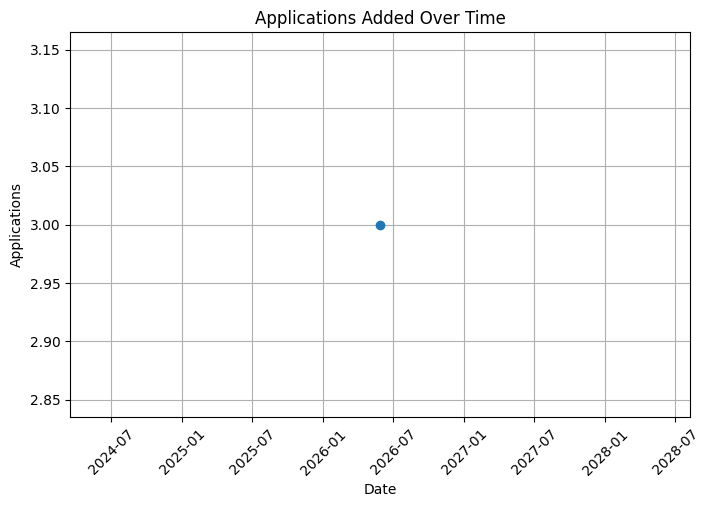

In [15]:
dates = []

for app in applications:

    dates.append(

        app["created"].date()

    )

trend = {}

for d in dates:

    trend[d] = trend.get(d,0)+1

x = list(trend.keys())

y = list(trend.values())

plt.figure(figsize=(8,5))

plt.plot(

    x,
    y,
    marker='o'

)

plt.title(

    "Applications Added Over Time"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Applications"

)

plt.xticks(rotation=45)

plt.grid()

plt.show()

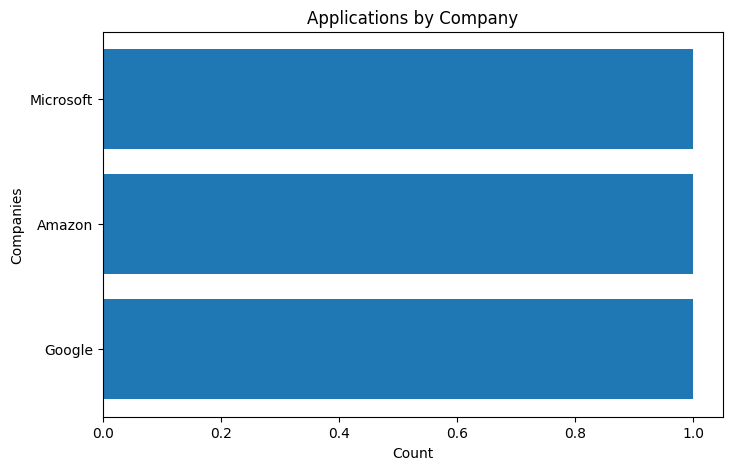

In [16]:
company_count = {}

for app in applications:

    c = app["company"]

    company_count[c] = company_count.get(c,0)+1

plt.figure(figsize=(8,5))

plt.barh(

    list(company_count.keys()),

    list(company_count.values())

)

plt.title(

    "Applications by Company"

)

plt.xlabel(

    "Count"

)

plt.ylabel(

    "Companies"

)

plt.show()

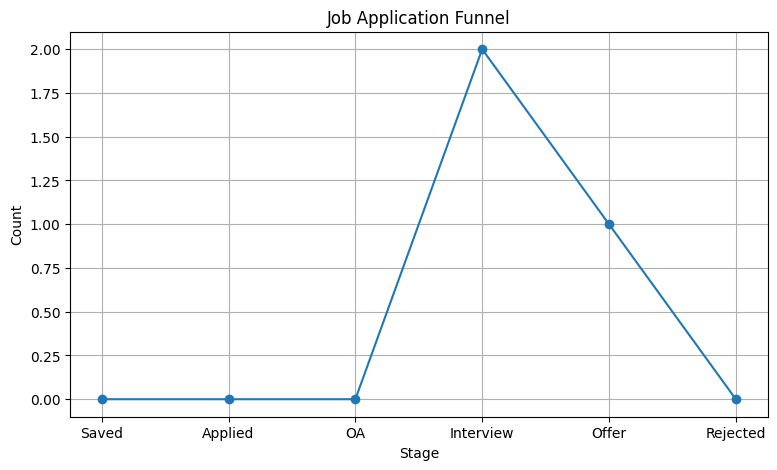

In [17]:
stages = [

    "Saved",
    "Applied",
    "OA",
    "Interview",
    "Offer",
    "Rejected"

]

counts = []

for stage in stages:

    count = 0

    for app in applications:

        if app["stage"] == stage:

            count += 1

    counts.append(count)

plt.figure(figsize=(9,5))

plt.plot(

    stages,
    counts,
    marker="o"

)

plt.title(

    "Job Application Funnel"

)

plt.xlabel(

    "Stage"

)

plt.ylabel(

    "Count"

)

plt.grid()

plt.show()